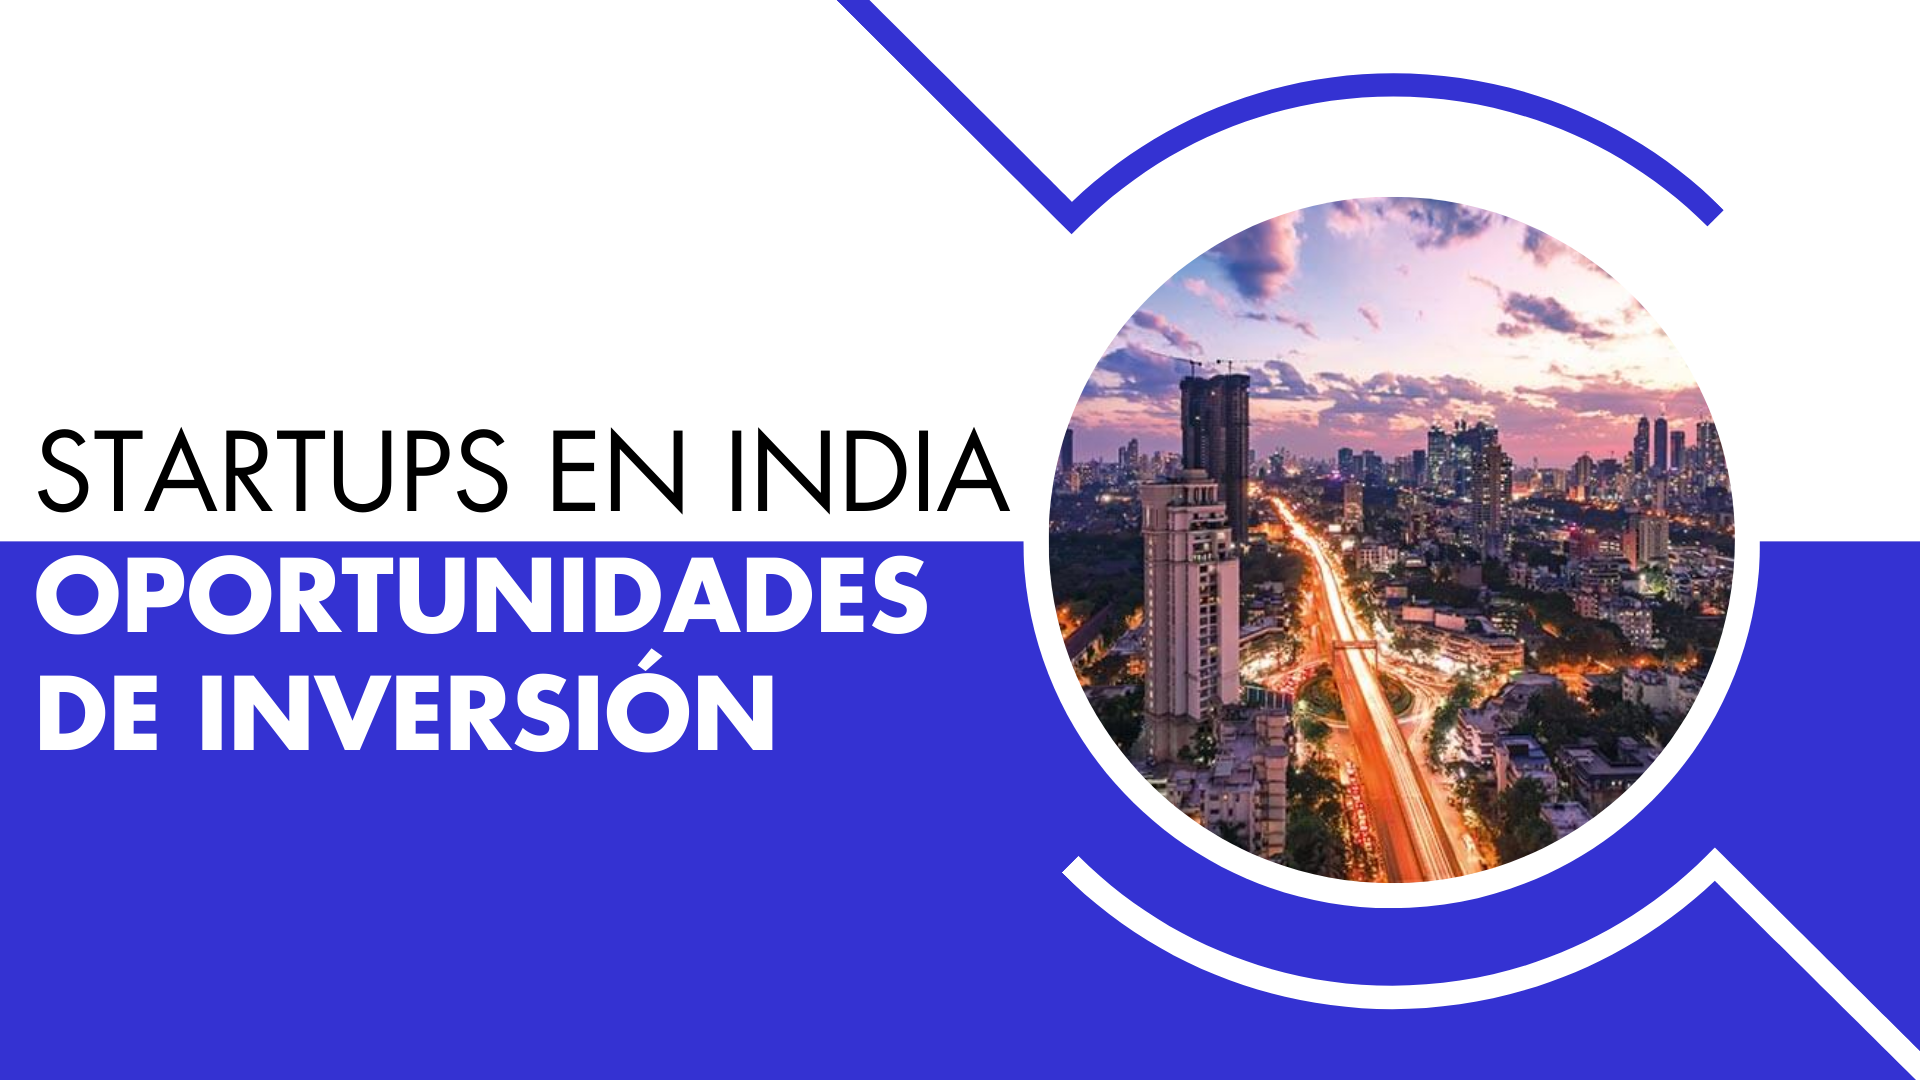

# Startup India Investments

## Abstract

El ecosistema de startups en India ha experimentado un crecimiento significativo en los últimos años, impulsado por la innovación y el acceso a financiamiento. Este proyecto analiza un conjunto de datos detallado sobre startups, incluyendo información sobre inversiones, financiamiento, tecnología, impacto ESG, rentabilidad y crecimiento.

El análisis permitirá desarrollar modelos predictivos para evaluar la viabilidad financiera y la rentabilidad de nuevas empresas, así como generar recomendaciones estratégicas para inversores y emprendedores. Los hallazgos obtenidos contribuirán a una mejor comprensión del mercado, optimizando la toma de decisiones en el ámbito del emprendimiento y la inversión en India.



## Objetivos

1. Desarrollar un modelo predictivo para estimar la rentabilidad de las startups, identificando los factores clave que influyen en su desempeño financiero.

2. Anticipar la probabilidad de que los fundadores logren monetizar su inversión y se retiren total o parcialmente del negocio, analizando patrones de éxito y condiciones del mercado.

3. Predecir la valoración de una startup tras recibir financiamiento, para estimar su potencial de mercado.



## Contexto comercial

El avance de las startups de base tecnológica, genera cada vez más atención por inversores . El análisis de este conjunto de datos puede allanar el camino para una mejor comprensión del panorama de inversiones, permitiendo a las partes interesadas tomar decisiones informadas que impacten significativamente en el crecimiento y la sostenibilidad de las startups en el mercado indio. Al aprovechar los conocimientos obtenidos de este conjunto de datos, emprendedores e inversores pueden posicionarse estratégicamente para capitalizar oportunidades emergentes y afrontar desafíos de manera efectiva.

## Contexto analítico

* Startup_ID: Identificador único de la startup.

* Name: Nombre de la startup.
* Sector: Sector en el que opera la startup (Retail, EdTech, AgriTech, HealthTech, TravelTech, FoodTech, FinTech).
* Sub-Sector: Categoría específica dentro del sector principal.
* City: Ciudad donde está ubicada la startup.
* State: Estado donde opera la startup.
* Founded_Year: Año de fundación de la startup.
* Founder_Name: Nombre del fundador o cofundadores de la startup.
* Funding_Stage: Etapa de financiamiento de la startup (Series D, IPO, Series A, Seed, Series B, Series C).
* Investment_Type: Tipo de inversión recibida (Grant, Convertible Note, Debt, Equity).
* Amount_Raised: Monto total de financiamiento obtenido por la startup.
* Investors_Count: Número total de inversores que han participado en el financiamiento.
* Lead_Investor: Inversor principal en la ronda de financiamiento.
* Co-Investors: Otros inversores que han participado en la ronda.
* Valuation_Post_Funding: Valoración de la startup después de recibir financiamiento.
* Revenue: Ingresos generados por la startup.
* Profitability: Estado de rentabilidad de la startup (Yes/No).
* Number_of_Employees: Cantidad de empleados en la startup.
* Tech_Stack: Tecnologías utilizadas por la startup (IoT, AR/VR, Blockchain, Big Data, AI, Cloud).
* Primary_Product: Producto o servicio principal ofrecido por la startup.
* Customer_Base_Size: Tamaño de la base de clientes de la startup.
* Growth_Rate: Tasa de crecimiento de la startup en términos de ingresos, clientes u otros factores.
* Exit_Status: Estado de salida de la startup (Yes/No).
* Acquisition_Details: Información sobre adquisiciones, si la startup ha sido comprada.
* Funding_Date: Fecha en la que la startup recibió financiamiento.
* Pitch_Deck_Link: Enlace al documento de presentación de la startup para inversores.
* Social_Media_Followers: Número de seguidores en redes sociales.
* Competitors: Empresas competidoras en el mercado.
* Patents: Número de patentes registradas por la startup.
* ESG_Score: Puntaje de desempeño en criterios ambientales, sociales y de gobernanza (ESG).
* Diversity_Index: Índice de diversidad dentro de la startup.
* Net_Impact_Score: Puntaje de impacto neto en la sociedad y el medio ambiente.

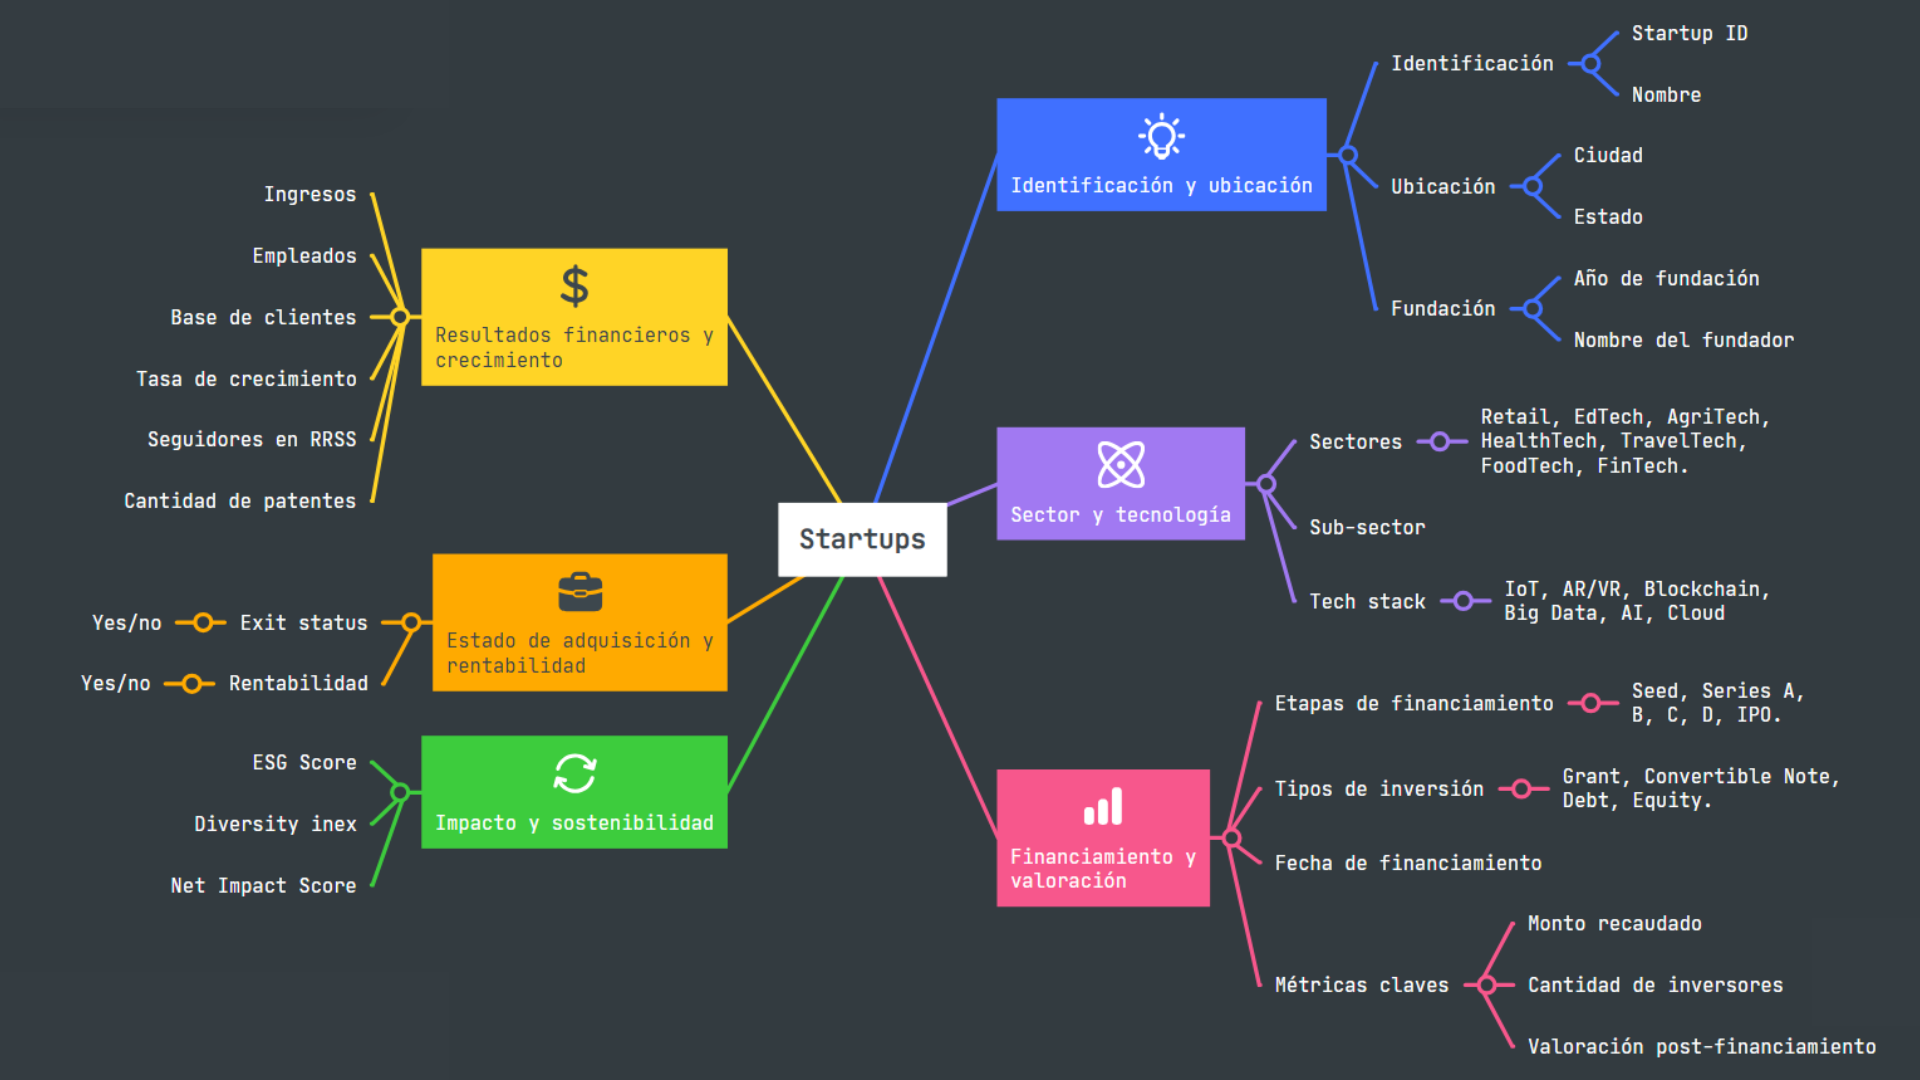

## Data Acquisition

In [58]:
# Importación de las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.subplots as sp
from sklearn.preprocessing import OrdinalEncoder
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from geopy.geocoders import Nominatim
import time
from geopy.extra.rate_limiter import RateLimiter

In [59]:
# Importación de la base de datos
url = "https://drive.google.com/uc?id="
ext = "1Q46toAmj4Dc3MIwlgvysLTXd0DeGZ44c"
startups_df = pd.read_csv(url+ext)

## Análisis exploratorio de datos (EDA)

### Exploración inicial

In [60]:
# Exploración de las primeras 5 filas del dataframe
startups_df.head()

,Startup_ID,Name,Sector,Sub-Sector,City,State,Founded_Year,Founder_Name,Funding_Stage,Investment_Type,...,Exit_Status,Acquisition_Details,Funding_Date,Pitch_Deck_Link,Social_Media_Followers,Competitors,Patents,ESG_Score,Diversity_Index,Net_Impact_Score
0,a713cd4f,Startup_0,Retail,Sub_2,Pune,Maharashtra,2022,Founder_356,Series D,Grant,...,No,NaN,2023-07-08,http://example.com/pitchdeck/0,27648,Competitor_88,11,5.32,39.33,4.71
1,b75f6987,Startup_1,EdTech,Sub_2,Pune,Karnataka,2019,Founder_93,IPO,Convertible Note,...,Yes,Acquirer_185,2017-01-02,http://example.com/pitchdeck/1,89143,Competitor_66,17,2.50,43.19,5.03
2,d5ba7ec2,Startup_2,AgriTech,Sub_7,Chennai,Tamil Nadu,2010,Founder_951,Series A,Grant,...,Yes,NaN,2022-06-20,http://example.com/pitchdeck/2,62445,Competitor_93,4,5.13,36.11,5.71
3,5190a643,Startup_3,HealthTech,Sub_8,Mumbai,Telangana,2007,Founder_538,IPO,Debt,...,Yes,NaN,2021-01-11,http://example.com/pitchdeck/3,30184,Competitor_31,13,9.14,31.38,9.29
4,a6801a40,Startup_4,HealthTech,Sub_6,Bangalore,Maharashtra,2019,Founder_69,Seed,Grant,...,No,NaN,2015-07-22,http://example.com/pitchdeck/4,56494,Competitor_27,0,8.10,78.20,1.12


In [61]:
# Exploración de la forma del dataframe
startups_df.shape

(12428, 32)

📑 ​El dataset contiene 32 columnas y 12.428 filas.

In [62]:
# Exploración de tipos de columnas
startups_df.dtypes.sort_values()

,0
Revenue,int64
Patents,int64
Social_Media_Followers,int64
Customer_Base_Size,int64
Founded_Year,int64
Number_of_Employees,int64
Valuation_Post_Funding,int64
Amount_Raised,int64
Investors_Count,int64
ESG_Score,float64


📑 Los tipos de datos son acordes a la información que muestran.
Se deben transformar las variables target: Exit_Status y Profitability a valores 0 y 1. Funding_Date debería modificarse el tipo de dato a fecha. No se tomará para el análisis, por lo cuál no se efectuará dicha transformación.



In [63]:
# Exploración de valores nulos
startups_df.isnull().sum().sort_values(ascending=False)

,0
Acquisition_Details,10027
Startup_ID,0
Sector,0
Name,0
City,0
State,0
Founded_Year,0
Sub-Sector,0
Funding_Stage,0
Investment_Type,0


📑​ La única variable que presenta valores nulos es Acquisition_Details. Es correcto que presente nulos, dado que depende de que la startup haya sido comprada. No corresponde efectuar ningún tratamiento sobre nulos.

In [64]:
# Exploración de datos duplicados por ID
startups_df[startups_df.duplicated(subset=["Startup_ID"], keep=False)]

,Startup_ID,Name,Sector,Sub-Sector,City,State,Founded_Year,Founder_Name,Funding_Stage,Investment_Type,...,Exit_Status,Acquisition_Details,Funding_Date,Pitch_Deck_Link,Social_Media_Followers,Competitors,Patents,ESG_Score,Diversity_Index,Net_Impact_Score


In [65]:
# Exploración de datos duplicados por nombre
startups_df[startups_df.duplicated(subset=["Name"], keep=False)]

,Startup_ID,Name,Sector,Sub-Sector,City,State,Founded_Year,Founder_Name,Funding_Stage,Investment_Type,...,Exit_Status,Acquisition_Details,Funding_Date,Pitch_Deck_Link,Social_Media_Followers,Competitors,Patents,ESG_Score,Diversity_Index,Net_Impact_Score


📑​ No existen registros duplicados, ya sea por ID de Startup como por el nombre.

In [66]:
# Exploración estadística de los datos
startups_df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Founded_Year,12428.0,2011.55,6.87,2000.0,2006.00,2012.00,2018.00,2023.00
Amount_Raised,12428.0,5022741.41,2859507.71,100101.0,2550872.00,5031528.50,7511475.50,9998407.00
Investors_Count,12428.0,5.50,2.86,1.0,3.00,6.00,8.00,10.00
Valuation_Post_Funding,12428.0,50378580.72,28543353.77,1018160.0,25274100.75,50486107.00,75189468.00,99991036.00
Revenue,12428.0,2530078.30,1409488.27,100013.0,1306538.25,2517865.00,3737343.25,4999381.00
Number_of_Employees,12428.0,256.46,140.63,10.0,135.00,256.00,377.00,500.00
Customer_Base_Size,12428.0,50464.86,28616.71,1004.0,25544.00,50305.50,75052.75,99994.00
Growth_Rate,12428.0,27.43,12.90,5.0,16.36,27.36,38.44,50.00
Social_Media_Followers,12428.0,50642.60,28518.03,1008.0,25872.75,50435.00,75531.75,99963.00
Patents,12428.0,9.90,6.10,0.0,5.00,10.00,15.00,20.00


📑 Las variables con mayor dispersión de datos son monto de financiamiento, valuación después de la inversión e ingresos.
En menor medida, la base de clientes y la cantidad de seguidores en RRSS presentan una elevada dispersión, pero en menor magnitud que las anteriores.

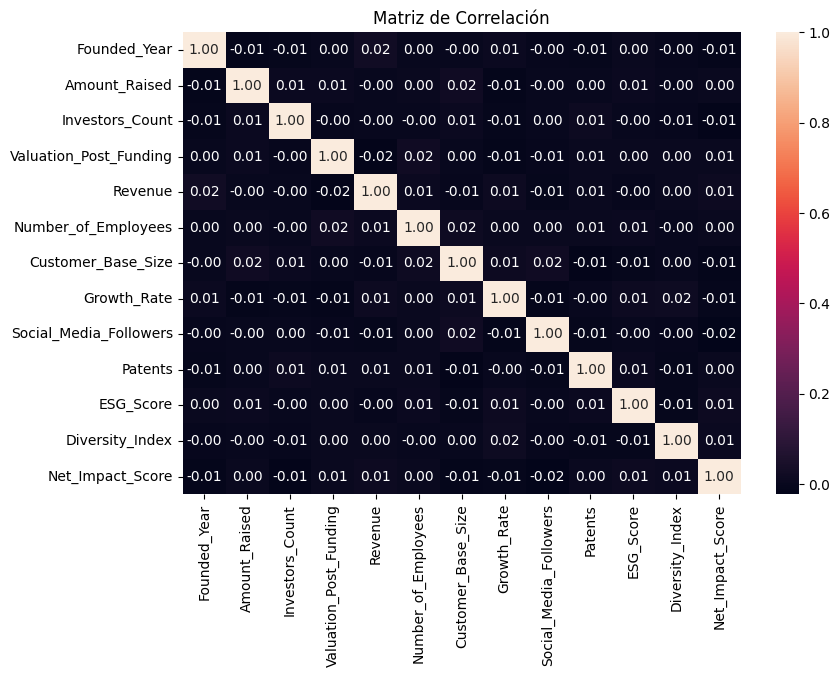

In [67]:
# Exploración de correlación entre variables

# Variables numéricas
startups_numerico= startups_df.select_dtypes(include='number')
startups_numerico.head()

matriz_corr_startups= startups_numerico.corr()
matriz_corr_startups

f, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(matriz_corr_startups, annot=True, fmt=".2f",ax=ax )
plt.title("Matriz de Correlación")
plt.show()

📑​ No existe correlación entre las variables numéricas. Las correlaciones se encuentran en un rango entre -0.02 y 0.02, lo que sugiere que las variables son independientes entre sí.


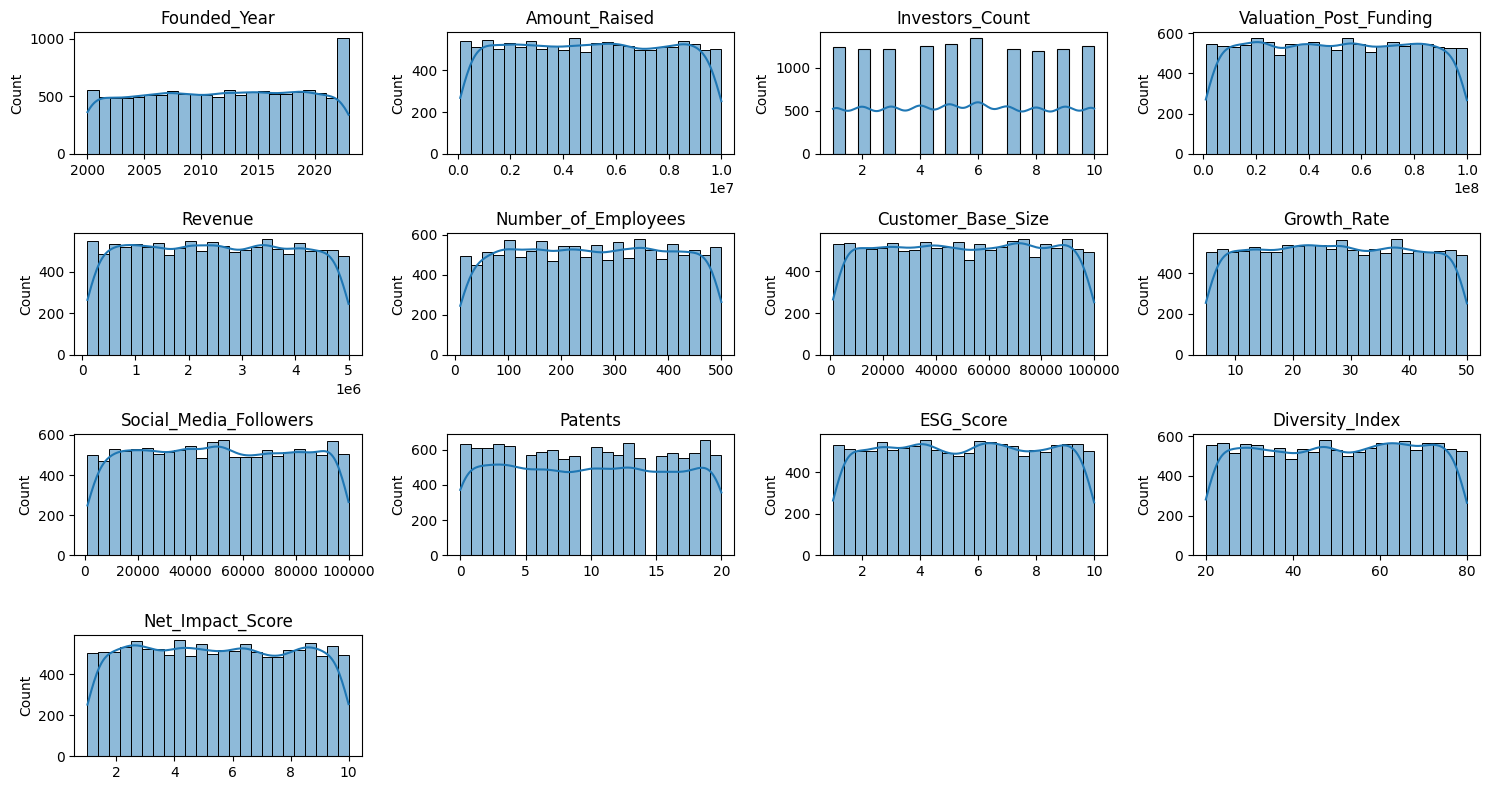

In [68]:
# Distribución de variables numéricas

variables = ['Founded_Year', 'Amount_Raised', 'Investors_Count',
       'Valuation_Post_Funding', 'Revenue', 'Number_of_Employees',
       'Customer_Base_Size', 'Growth_Rate', 'Social_Media_Followers',
       'Patents', 'ESG_Score', 'Diversity_Index', 'Net_Impact_Score']
columns = 4
rows = (len(variables) + columns - 1) // columns
fig, axes = plt.subplots(rows, columns, figsize=(15, 8))

if rows == 1:
    axes = [axes]

for current_idx, variable in enumerate(variables):
    i = current_idx // columns
    j = current_idx % columns
    sns.histplot(startups_df[variable], ax=axes[i][j], kde=True)
    axes[i][j].set_title(variable)
    axes[i][j].set_xlabel("")

for idx in range(current_idx + 1, rows * columns):
    axes[idx // columns][idx % columns].set_visible(False)

plt.tight_layout()
plt.show()

📑​ La mayoría de las variables presentan una distribución uniforme, lo cual indica una buena variedad de startups con características diferentes. No se presenta concentración en valores específicos.

In [69]:
# Exploración de valores atípicos y outliers

# Definir el número de columnas
columns = 5
rows = (len(variables) + columns - 1) // columns  # Calcular el número de filas necesarias

# Crear un grid de subgráficas
fig = sp.make_subplots(rows=rows, cols=columns, subplot_titles=variables)

# Agregar cada gráfico de caja al grid
for idx, variable in enumerate(variables):
    row = idx // columns + 1  # Calcular la fila
    col = idx % columns + 1    # Calcular la columna
    box_fig = px.box(startups_df, y=variable)

    # Añadir la figura de caja al grid
    for trace in box_fig.data:
        fig.add_trace(trace, row=row, col=col)

# Actualizar el layout
fig.update_layout(height=950, width=1600, showlegend=False)
fig.show()

📑 No se detectan valores atípicos. Además, las distribuciones son uniformes.

### **Variables objetivo**

In [70]:
# Panel de Gráficos: Exit_Status, Profitability y Valuation_Post_Funding
# Calcular proporciones de Exit_Status
exit_status_counts = startups_df['Exit_Status'].value_counts()
exit_status_labels = exit_status_counts.index
exit_status_values = exit_status_counts.values

# Calcular proporciones de Profitability
profitability_counts = startups_df['Profitability'].value_counts()
profitability_labels = profitability_counts.index
profitability_values = profitability_counts.values

# Crear subgráficos
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=('Proporción de Exit_Status', 'Proporción de Profitability', 'Histograma de Valuation_Post_Funding'),
                    specs=[[{'type': 'pie'}, {'type': 'pie'}, {'type': 'histogram'}]])

# Gráfico de anillo de Exit_Status
fig.add_trace(go.Pie(labels=exit_status_labels,
                      values=exit_status_values,
                      hole=0.4,
                      name='Exit_Status',
                      textinfo='label+percent',
                      marker=dict(colors=['#1f77b4', '#6baed6'])),  # Tonos de azul
              row=1, col=1)

# Gráfico de anillo de Profitability
fig.add_trace(go.Pie(labels=profitability_labels,
                      values=profitability_values,
                      hole=0.4,
                      name='Profitability',
                      textinfo='label+percent',
                      marker=dict(colors=['#3182bd', '#9ecae1'])),  # Tonos de azul
              row=1, col=2)

# Histograma de Valuation_Post_Funding
fig.add_trace(go.Histogram(x=startups_df['Valuation_Post_Funding'],
                             name='Valuation_Post_Funding',
                             marker_color='#4575b4',  # Color azul para el histograma
                             nbinsx=20),
              row=1, col=3)

# Actualizar el diseño del gráfico
fig.update_layout(title_text='Panel de Gráficos: Exit_Status, Profitability y Valuation_Post_Funding',
                  height=400,
                  showlegend=False)

# Mostrar el gráfico
fig.show()

📑La proporción entre las categorías de Exit_status y profitability son equilibradas.
En cuanto a valuation_post_funding, se observa una mayor cantidad de observaciones entre 20M y 25M y una menor cantidad entre 0 y 5M.

### **Análisis temporal**

In [71]:
# Top 5 de años con mayor cantidad de registros

startups_por_año = startups_df['Founded_Year'].value_counts()
top_5_años = startups_por_año.head(5)
top_5_años

,count
Founded_Year,
2012,557
2019,554
2000,554
2015,548
2007,547


📑 Los años con mayor cantidad de startups fundadas han sido 2000, 2007, 2012, 2015 y 2019.

In [72]:
# Tendencia de fundación de startups a lo largo del tiempo

startups_por_año = startups_df['Founded_Year'].value_counts().sort_index()

fig_line = px.line(x=startups_por_año.index,
                    y=startups_por_año.values,
                    labels={'x': 'Año', 'y': 'Cantidad de Startups'},
                    title='Tendencia de Fundación de Startups a lo Largo del Tiempo',
                    markers=True)
fig_line.show()

📑La cantidad de startups en el tiempo no es constante ni posee un crecimiento continuo. Se observa fases de crecimiento y decrecimiento.

In [73]:
# Tasa decrecimiento anual de startups (%)

startups_por_año = startups_df['Founded_Year'].value_counts().sort_index()
crecimiento_anual = startups_por_año.pct_change() * 100

fig_crecimiento = go.Figure(data=[go.Bar(x=crecimiento_anual.index,
                                       y=crecimiento_anual.values,
                                       marker_color=crecimiento_anual.apply(lambda x: 'blue' if x > 0 else 'purple'))])

fig_crecimiento.update_layout(title='Tasa de Crecimiento Anual de Startups (%)',
                             xaxis_title='Año',
                             yaxis_title='Tasa de Crecimiento (%)')
fig_crecimiento.show()

📑Se puede observar que hay fases de crecimiento y decrecimiento de la cantidad de startups en el tiempo. Se puede observar el siguiente patrón: si las tasas son crecientes por 4 años, luego las tasas son decrecientes por el mismo período de tiempo.

### **Análisis territorial**

In [74]:

# Inicializar geolocalizador con timeout y user agent
geolocator = Nominatim(user_agent="startups_mapper", timeout=10)
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)  # Espera entre requests

# Conteo de ciudades
city_counts = startups_df['City'].value_counts().reset_index()
city_counts.columns = ['City', 'Count']
city_counts = city_counts.sort_values('Count', ascending=True)

# Crear lista de ciudades únicas
unique_cities = city_counts['City'].unique()

# Diccionario para guardar coordenadas
city_coords = {}

# Obtener coordenadas para cada ciudad
for city in unique_cities:
    if city not in city_coords:
        try:
            location = geocode(f"{city}, India")
            if location:
                city_coords[city] = (location.latitude, location.longitude)
            else:
                city_coords[city] = (None, None)
        except Exception as e:
            print(f"Error en la ciudad: {city} -> {e}")
            city_coords[city] = (None, None)

# Asignar coordenadas a dataframe
city_counts['lat'] = city_counts['City'].map(lambda x: city_coords.get(x, (None, None))[0])
city_counts['lon'] = city_counts['City'].map(lambda x: city_coords.get(x, (None, None))[1])


In [75]:
# Creación del mapa de startups

fig = px.scatter_mapbox(city_counts,
                        lat="lat",
                        lon="lon",
                        size="Count",
                        color="Count",
                        hover_name="City",
                        hover_data={"Count": True, "lat": False, "lon": False},
                        color_continuous_scale=px.colors.sequential.Plasma,
                        size_max=25,
                        zoom=3.5,  # Alejamos el zoom
                        title="Mapa de Startups por Ciudad en India")

# Estilo plano
fig.update_layout(mapbox_style="carto-positron")

# Centramos el mapa en India
fig.update_layout(mapbox_center={"lat": 22.5, "lon": 80})

# Layout más limpio
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

📑 La ciudad con mayor desarrollo de startups es Bangalore, seguida de Mumbai y Delhi.
Chennai es la ciudad con menor cantidad de startups.

In [76]:
# Gráfico de barras con la suma de Revenue por ciudad
city_revenue = startups_df.groupby('City')['Revenue'].mean().reset_index()
city_revenue = city_revenue.sort_values('Revenue', ascending=True)

fig = px.bar(city_revenue,
             y='City',
             x='Revenue',
             labels={'City': 'Ciudad', 'Revenue': 'Ingresos promedio'},
             title='Ingresos promedio por Ciudad',
             color='Revenue',
             color_continuous_scale=["#A0C4FF", "#007BFF","#0056B3", "#003F7F"])

fig.update_layout(showlegend=False)

fig.show()

📑 Pune y Delhi son las ciudades con mayor nivel de ingresos promedios por startup.

### **Análisis sectorial**

In [77]:
# Distribución de startups por sector

sector_counts = startups_df['Sector'].value_counts().reset_index()
sector_counts.columns = ['Sector', 'Count']

fig = px.bar(sector_counts,
             x='Sector',
             y='Count',
             title='Distribución de Startups por Sector',
             labels={'Sector': 'Sector', 'Count': 'Cantidad de Startups'},
             color='Count',  # Mapeo de colores basado en los valores de 'Count'
             color_continuous_scale=["#A0C4FF", "#007BFF", "#0056B3", "#003F7F"])  # Escala de colores personalizada

fig.update_layout(showlegend=False)

fig.show()

📑 La mayor cantidad de startups son del sector Fintech, y la menor cantidad son de EdTech.

In [78]:
# Valuación post inversión por sector
startups_df['Valuation_Post_Funding'] = pd.to_numeric(startups_df['Valuation_Post_Funding'], errors='coerce')

# Crear el gráfico de violín con tonos de azul oscuro
dark_blue_colors = ['#001f3f', '#003366', '#004080', '#00509E', '#0073A8']  # Lista de colores azules oscuros

fig = px.violin(startups_df,
                 x='Sector',
                 y='Valuation_Post_Funding',
                 box=True,
                 title='Distribución de Valuation_Post_Funding por Sector',
                 labels={'Valuation_Post_Funding': 'Valuation Post Funding', 'Sector': 'Sector'},
                 color='Sector',
                 color_discrete_sequence=dark_blue_colors)  # Usar la lista de colores azules oscuros
fig.update_layout(showlegend=False)

fig.show()

📑No existen diferencias significativas en la valuación después de invertir en las startups según el sector. Las distribuciones son similares. Cada sector tiene una forma similar, lo que indica que la distribución de las valoraciones post-financiamiento no varía demasiado entre ellos.

Se observa que la mayor densidad de datos se encuentra en valores más bajos, lo que sugiere que la mayoría de las startups tienen valoraciones post-financiamiento más reducidas.



In [79]:
# Proporciones de Exit_Status y Profitability por Sector
# Agrupar por Sector y Exit_Status
exit_status_counts = startups_df.groupby(['Sector', 'Exit_Status']).size().unstack(fill_value=0)
exit_status_proportions = exit_status_counts.div(exit_status_counts.sum(axis=1), axis=0)

# Agrupar por Sector y Profitability
profitability_counts = startups_df.groupby(['Sector', 'Profitability']).size().unstack(fill_value=0)
profitability_proportions = profitability_counts.div(profitability_counts.sum(axis=1), axis=0)

# Convertir a DataFrame para Plotly
exit_status_proportions = exit_status_proportions.reset_index()
profitability_proportions = profitability_proportions.reset_index()

# Crear subgráficos
fig = make_subplots(rows=1, cols=2, subplot_titles=('Proporción de Exit_Status por Sector', 'Proporción de Profitability por Sector'))

# Definir colores para el gráfico de Exit_Status
exit_status_colors = ['#9467bd', '#1f77b4']  # Azul para Yes, violeta para No

# Añadir gráfico de Exit_Status
for i, status in enumerate(exit_status_proportions.columns[1:]):
    fig.add_trace(go.Bar(
        x=exit_status_proportions['Sector'],
        y=exit_status_proportions[status],
        name=status,
        hoverinfo='y+name',
        marker_color=exit_status_colors[i],
        showlegend=True
    ), row=1, col=1)

# Definir colores para el gráfico de Profitability
profitability_colors = ['#9467bd', '#1f77b4']  # Azul para Yes, violeta para No

# Añadir gráfico de Profitability
for i, status in enumerate(profitability_proportions.columns[1:]):
    fig.add_trace(go.Bar(
        x=profitability_proportions['Sector'],
        y=profitability_proportions[status],
        name=status,
        hoverinfo='y+name',
        marker_color=profitability_colors[i],
        showlegend=True
    ), row=1, col=2)

# Actualizar el diseño del gráfico
fig.update_layout(
    title_text='Proporciones de Exit_Status y Profitability por Sector',
    barmode='group',
    xaxis_title='Sector',
    yaxis_title='Proporción',
    xaxis2_title='Sector',
    yaxis2_title='Proporción',
    height=400
)

# Mostrar el gráfico
fig.show()

📑 En general, se mantiene la proporción de exit_status y profitability en los sectores. A destacar:
* FoodTech y FinTech tienen mayor proporción de valores positivos para exit_status. Es decir, que tienden a que los fundadores se retiren de la startup.
* EdTech y TravelTech tienen menor proporción de valores positivos para exit_status. Es decir, que es menos probable de que los fundadores se retiren.
* TravelTech es el sector con mayor proporción de startups rentables.
* FoodTech es el sector con menor proporción de startups rentables.

### **Análisis de inversiones**

In [80]:
# @title
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import numpy as np

# Conteo por tipo de inversión
investment_counts = startups_df['Investment_Type'].value_counts()
investment_labels = investment_counts.index
investment_values = investment_counts.values

# Calcular la mediana general
median_value = startups_df['Valuation_Post_Funding'].median()

# Función para formatear la mediana
def format_median(value):
    return f"{value / 1_000_000:.2f}M" if value >= 1_000_000 else f"{value:.2f}"

# Crear subgráficos
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Distribución por Tipo de Inversión', 'Distribución de Valuación Post Financiamiento'),
                    specs=[[{'type': 'pie'}, {'type': 'violin'}]])

# Gráfico de anillo de Investment_Type
fig.add_trace(go.Pie(labels=investment_labels,
                      values=investment_values,
                      hole=0.4,
                      name='Investment_Type',
                      textinfo='label+percent',
                      marker=dict(colors=['#08306b', '#08519c', '#2171b5', '#4292c6', '#6baed6', '#9ecae1'])),
              row=1, col=1)

# Gráfico de violín de Valuation_Post_Funding
fig.add_trace(go.Violin(x=startups_df['Investment_Type'],
                         y=startups_df['Valuation_Post_Funding'],
                         box=dict(fillcolor='lightblue'),  # Configuración del cuadro
                         line_color='blue',
                         name='Valuation_Post_Funding',
                         marker_color='#9467bd'),
              row=1, col=2)

# Agregar línea de mediana general al gráfico de violín
fig.add_shape(type='line',
              x0=-0.5, x1=len(startups_df['Investment_Type'].unique()) - 0.5,
              y0=median_value, y1=median_value,
              line=dict(color='red', width=2, dash='dash'),
              row=1, col=2)

# Agregar anotación para la mediana
formatted_median = format_median(median_value)  # Formatear la mediana
fig.add_annotation(x=len(startups_df['Investment_Type'].unique()) - 0.5,
                   y=median_value,
                   text=f'Mediana: {formatted_median}',
                   showarrow=True,
                   arrowhead=2,
                   ax=0,
                   ay=-40,
                   row=1, col=2)

# Actualizar el diseño del gráfico
fig.update_layout(title_text='Análisis de inversiones',
                  height=400,
                  showlegend=False)

# Mostrar el gráfico
fig.show()

📑 Los tipos de inversión están balanceados (representando un 25% del total cada categoría).

La valuación post financiamiento es independiente del tipo de inversión. Ronda en una mediana de 50M. En los gráficos Se ven concentraciones alrededor de los 20M, 50M y 90M en varias categorías, lo que sugiere que muchas startups tienden a alcanzar ciertos “escalones” de valuación.



In [81]:
# Análisis de inversiones
# Calcular la proporción de Profitability por Investment_Type
profitability_counts = startups_df.groupby(['Investment_Type', 'Profitability']).size().unstack(fill_value=0)
profitability_proportions = profitability_counts.div(profitability_counts.sum(axis=1), axis=0)

# Calcular la proporción de Exit_Status por Investment_Type
exit_status_counts = startups_df.groupby(['Investment_Type', 'Exit_Status']).size().unstack(fill_value=0)
exit_status_proportions = exit_status_counts.div(exit_status_counts.sum(axis=1), axis=0)

# Crear subplots
fig = sp.make_subplots(rows=1, cols=2, subplot_titles=("Proporción de Profitability", "Proporción de Exit_Status"))

# Definir una gama de colores oscuros en azul
blue_colors = ['#004080', '#0073E6']

# Añadir trazas para Profitability
for i, profitability in enumerate(profitability_proportions.columns):
    fig.add_trace(go.Bar(
        x=profitability_proportions.index,
        y=profitability_proportions[profitability],
        name=profitability,
        text=profitability_proportions[profitability].apply(lambda x: f"{x:.1%}"),  # Formato de porcentaje
        textposition='inside',
        marker_color=blue_colors[i % len(blue_colors)]  # Asignar color de la gama
    ), row=1, col=1)

# Añadir trazas para Exit_Status
for i, exit_status in enumerate(exit_status_proportions.columns):
    fig.add_trace(go.Bar(
        x=exit_status_proportions.index,
        y=exit_status_proportions[exit_status],
        name=exit_status,
        text=exit_status_proportions[exit_status].apply(lambda x: f"{x:.1%}"),  # Formato de porcentaje
        textposition='inside',
        marker_color=blue_colors[i % len(blue_colors)]  # Asignar color de la gama
    ), row=1, col=2)

# Actualizar el diseño del gráfico
fig.update_layout(
    title='Análisis de inversiones',
    barmode='stack',
    yaxis_title='Proporción',
    xaxis_title='Tipo de Inversión',
    height=600
)

# Mostrar el gráfico
fig.show()

📑Si bien los tipos de inversiones están balanceados, se ve una leve superioridad en debt, que sugiere que el 50,8% de los casos han sido rentables y que el 51,2% de startups los socios han retirado su parte. Esto lo posiciona como el tipo de inversión potencialmente más atractivo.

### **Análisis de indicadores claves**

In [82]:
# Radar de variables financieras y de comercialización
# Variables a incluir en el radar
variables_radar = [
    'Revenue', 'Number_of_Employees', 'Customer_Base_Size',
    'Social_Media_Followers', 'Patents'
]

# 1. Normalización Min-Max
startups_normalized = startups_df.copy()
for var in variables_radar:
    min_val = startups_df[var].min()
    max_val = startups_df[var].max()
    startups_normalized[var] = (startups_df[var] - min_val) / (max_val - min_val)

# 2. Agrupar por Profitability y calcular la media
radar_data = startups_normalized.groupby('Profitability')[variables_radar].mean().reset_index()

# 3. Crear el gráfico de radar con Plotly
fig = go.Figure()

# Añadir cada grupo (Yes/No) al radar
for profitability in radar_data['Profitability'].unique():
    subset = radar_data[radar_data['Profitability'] == profitability]
    fig.add_trace(go.Scatterpolar(
        r=subset[variables_radar].values.flatten().tolist(),
        theta=variables_radar,
        fill='toself',
        name=f'Profitability = {profitability}',
        line_color='green' if profitability == 'Yes' else 'red'
    ))

# Personalizar el gráfico
fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]  # Rango de valores normalizados
        )),
    title='Comparación de Startups por Rentabilidad (Variables Normalizadas)',
    showlegend=True
)

fig.show()

📑 No se observan diferencias significativas entre las medidas de variables financieras y de comercialización entre startups con rentabilidad en sus dos categorías (Yes/ No).
En cantidad de seguidores en RRSS y cantidad de empleados, se observa mayor proporción en la categoría no rentable.
En cuanto a la categoría rentable, es ligeramente superior la tasa de crecimiento.

In [83]:
# Variables a incluir en el radar
variables_radar = ['ESG_Score', 'Growth_Rate', 'Diversity_Index']

# 1. Normalización Min-Max
startups_normalized = startups_df.copy()
for var in variables_radar:
    min_val = startups_df[var].min()
    max_val = startups_df[var].max()
    startups_normalized[var] = (startups_df[var] - min_val) / (max_val - min_val)

# 2. Agrupar por Profitability y calcular la media
radar_data = startups_normalized.groupby('Profitability')[variables_radar].mean().reset_index()

# 3. Crear el gráfico de radar con Plotly
fig = go.Figure()

# Colores y transparencias
colors = {'Yes': 'rgba(0, 128, 0, 0.6)', 'No': 'rgba(255, 0, 0, 0.6)'}  # Verde y rojo con transparencia

# Añadir cada grupo al radar
for profitability in radar_data['Profitability'].unique():
    subset = radar_data[radar_data['Profitability'] == profitability]
    fig.add_trace(go.Scatterpolar(
        r=subset[variables_radar].values.flatten().tolist(),
        theta=variables_radar,
        fill='toself',
        name=f'Profitability = {profitability}',
        fillcolor=colors[profitability],
        line=dict(color=colors[profitability].replace('0.6', '1'))  # Línea más opaca
    ))

# Personalización del gráfico
fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1],
            tickvals=[0, 0.2, 0.4, 0.6, 0.8, 1],
            ticktext=['0', '0.2', '0.4', '0.6', '0.8', '1']
        )),
    title='Comparación de Startups: ESG, Crecimiento y Diversidad (Normalizado)',
    legend=dict(orientation='v', yanchor='bottom', y=1.1),
    margin=dict(l=100, r=100, t=100, b=100)
)

fig.show()

📑 No se encuentran diferencias significativas entre las categorías de rentabilidad para las variables de impacto y sostenibilidad

### **Inisghts del análisis exploratorio**
💡**Exploración inicial**

El dataset no presenta datos duplicados, datos ausentes en variables críticas ni outliers.

Existen variables que no aportan valor al análisis, por lo que se deben excluir del dataframe. Las mismas son: Startup_ID, Sub-Sector, State, Founder_Name, Lead_Investor, Co-Investors, Primary_Product, Acquisition_Details, Pitch_Deck_Link, Competitors y Funding_Date.

Se deben efectuar transformaciones de las siguientes variables categóricas:
- Sin orden específico: Sector y Tech_Stack. Se aplicará one hot encoding.
- Con orden específico: Funding_Stage e Investment_Type. Se aplicará ordinal encoding.

💡 **Variables objetivo**

A priori, las variables objetivo Exit_Status y Profitability se encuentran equilibradas. Es decir, las startups tienen igual de posibilidades de tener éxito o fracaso en ambas. El desafío será encontrar cuáles son los factores determinantes y predecir tanto la salida de los fundadores como la rentabilidad.

Con respecto a la valuación después de invertir, se observa una mayor cantidad de observaciones entre 20M y 25M y una menor cantidad entre 0 y 5M. Si bien, existe una alta varianza de los datos, la valuación varía entre 1M y 99M de dólares.

💡 **Análisis temporal**

La cantidad de startups en el tiempo ha fluctuado, en ciclos de crecimiento y decrecimiento, siendo los años con mayor cantidad de startups fundadas en  2000, 2007, 2012, 2015 y 2019. No hay un patrón de cuándo se dan estos picos máximos.

Se deberían analizar variables económicas para estudiar si existe relación con la fundación de nuevas startups.


💡 **Análisis territorial**

Existe una oportunidad de expansión de las startups en diferentes ciudades de India. En el centro y norte del país (exceptuando a Delhi) no se han registrado emprendimientos de base tecnológica. Además, ciudades importantes como Calcuta, Ahmedabad y Surat, pueden ser foco de innovación.

💡 **Análisis sectorial**

El sector más atractivo para las startups es el Fintech. Asimismo, el menos elegido es el EdTech.

Por otra parte, los sectores FoodTech y FinTech tienden a que los fundadores se retiren de la startup. Para los casos de EdTech y TravelTech, es menos probable que los fundadores se retiren.
Por último, TravelTech es el sector con mayor proporción de startups rentables.

Si bien se han destacado sectores de acuerdo a las variables target, las diferencias no son significativas, por ende, todas son opciones válidas de inversión.


💡 **Análisis de inversiones**

No existe un tipo de inversión preferido por las startups, cada uno tiene una participación del 25% sobre el total. El tipo de inversión no limita directamente la valuación alcanzada. Se puede concluir que muchas startups tienden a alcanzar ciertos “escalones” de valuación (20M, 50M y 90M).

Tanto en rentabilidad como en salida de los socios fundadores, no existe un tipo de inversión que ofrezca condiciones superiores. Se destaca debt como una opción más atractiva por un porcentaje superior de startups que han sido rentables y con la salida de los fundadores de las respectivas sociedades.


💡 **Análisis de indicadores claves**

- El **monto de financiamiento** obtenido por las startups varía entre 1M y 99,98M. En promedio reciben 50M por startup. Es una de las variables con mayor dispersión. En total, las startups han recibido 62.422M. En los modelos predictivos, puede ser una variable clave.

- La **cantidad de inversores** que han participado en el financiamiento de startups es de 68.318. Por startup entre 1 y 10 inversores apuestan a emprendimientos con base tecnológica en India.
- La **rentabilidad** es otra variable con alta variabilidad. La misma se mueve en un rango de 100m y 50M de dólares. En promedio, las startups poseen una rentabilidad de 25,3M
- La **tasa de crecimiento** 27,43/50. El valor fluctúa entre 5 y 50 puntos. Existe un potencial de crecimiento del nivel global de las startups de India.
- Con respecto a las **métricas de diversidad y ambientales**, los promedios se encuentran al 50% del valor total. Es decir, existe un potencial de mejora para las mismas. Dichas variables presentan una distribución uniforme (no se detectan patrones o tendencias). Al comparar las categorías de las variables objetivos, no se detectan diferencias significativas al analizar las métricas de diversidad y ambientales.

En conclusión, no se detectan patrones a simple vista. Requiere del desarrollo de modelos con herramientas de machine learning para lograr los objetivos de predicción.


## Data Wrangling

In [84]:
startups_df_encoded = startups_df.copy()

In [85]:
# Aplicar One-Hot Encoding
startups_df_encoded = pd.get_dummies(startups_df_encoded, columns=['Sector', 'Tech_Stack'], drop_first=True)

# Aplicar Ordinal Encoding
funding_stage_order = ['Seed', 'Series A', 'Series B', 'Series C', 'Series D', 'IPO']
investment_type_order = ['Grant', 'Convertible Note', 'Debt', 'Equity']

ordinal_encoder = OrdinalEncoder(categories=[funding_stage_order, investment_type_order])
startups_df_encoded[['Funding_Stage', 'Investment_Type']] = ordinal_encoder.fit_transform(
    startups_df_encoded[['Funding_Stage', 'Investment_Type']]
)


In [86]:
startups_df_encoded.columns

Index(['Startup_ID', 'Name', 'Sub-Sector', 'City', 'State', 'Founded_Year',
       'Founder_Name', 'Funding_Stage', 'Investment_Type', 'Amount_Raised',
       'Investors_Count', 'Lead_Investor', 'Co-Investors',
       'Valuation_Post_Funding', 'Revenue', 'Profitability',
       'Number_of_Employees', 'Primary_Product', 'Customer_Base_Size',
       'Growth_Rate', 'Exit_Status', 'Acquisition_Details', 'Funding_Date',
       'Pitch_Deck_Link', 'Social_Media_Followers', 'Competitors', 'Patents',
       'ESG_Score', 'Diversity_Index', 'Net_Impact_Score', 'Sector_EdTech',
       'Sector_FinTech', 'Sector_FoodTech', 'Sector_HealthTech',
       'Sector_Retail', 'Sector_TravelTech', 'Tech_Stack_AR/VR',
       'Tech_Stack_Big Data', 'Tech_Stack_Blockchain', 'Tech_Stack_Cloud',
       'Tech_Stack_IoT'],
      dtype='object')

In [87]:
# mostrar los valores únicos de la columna Funding_Stage en startups_df_encoded
startups_df_encoded['Funding_Stage'].unique()

array([4., 5., 1., 0., 2., 3.])

In [88]:
# mostrar los valores únicos de la columna Investment_Type en startups_df_encoded
startups_df_encoded['Investment_Type'].unique()

array([0., 1., 2., 3.])

In [89]:
# Convertir columnas booleanas Yes/No a 1/0
startups_df_encoded['Profitability'] = startups_df_encoded['Profitability'].map({'Yes': 1, 'No': 0})
startups_df_encoded['Exit_Status'] = startups_df_encoded['Exit_Status'].map({'Yes': 1, 'No': 0})

In [90]:
# mostrar los valores únicos de la columna Profitability en startups_df_encoded
startups_df_encoded['Profitability'].unique()

array([0, 1])

In [91]:
# mostrar los valores únicos de la columna Exit_Status en startups_df_encoded
startups_df_encoded['Exit_Status'].unique()

array([0, 1])

In [92]:
columnas_a_excluir = [
    'Startup_ID',
    'Sub-Sector',
    'State',
    'Founder_Name',
    'Lead_Investor',
    'Co-Investors',
    'Primary_Product',
    'Acquisition_Details',
    'Pitch_Deck_Link',
    'Competitors',
    'Name',
    'City',
    'Funding_Date'

]

startups_df_cleaned = startups_df_encoded.drop(columns=columnas_a_excluir)


📑 Se han efectuado las siguientes transformaciones:

- Se utilizó One-Hot Encoding para transformar las variables Sector y Tech_Stack en varias columnas binarias (0 o 1).

- Para el caso de las variables que tienen un orden, Funding_Stage e Investment_Type, se transformaron en numéricas a través de Ordinal Encoding, según el orden definido.

- Por otra parte, se han convertido las variables objetivo con categorías Yes/ No, en valores 1 y 0 respectivamente.

- Por último, se eliminaron las variables no relevantes para el proyecto.

El dataframe permitirá trabajar con las variables mencionadas en modelos de Machine Learning.

## Modelos de Machine learning

### Predicción de variable Profitability

Matriz de Confusión:
 [[1107  774]
 [1146  702]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.49      0.59      0.54      1881
           1       0.48      0.38      0.42      1848

    accuracy                           0.49      3729
   macro avg       0.48      0.48      0.48      3729
weighted avg       0.48      0.49      0.48      3729

Accuracy: 0.48511665325824616


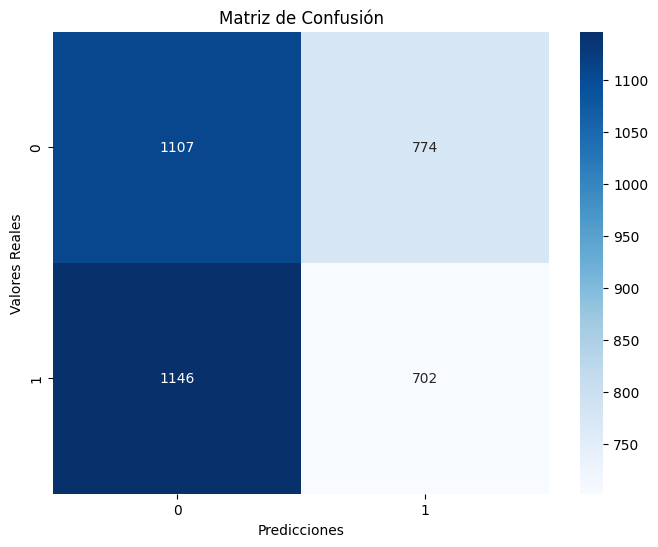

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Definir variables predictoras y objetivo
X = startups_df_cleaned.drop(columns=['Profitability'])
y = startups_df_cleaned['Profitability']

# 2. División de datos en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Entrenamiento del modelo Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=10)
rf_model.fit(X_train, y_train)

# 4. Predicciones
y_pred = rf_model.predict(X_test)

# 5. Evaluación del modelo
cm = confusion_matrix(y_test, y_pred)

print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# 6. Visualización de la Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel('Predicciones')
plt.ylabel('Valores Reales')
plt.title('Matriz de Confusión')
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



Matriz de Confusión:
 [[ 843 1038]
 [ 840 1008]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.50      0.45      0.47      1881
           1       0.49      0.55      0.52      1848

    accuracy                           0.50      3729
   macro avg       0.50      0.50      0.50      3729
weighted avg       0.50      0.50      0.50      3729

Accuracy: 0.49637972646822204


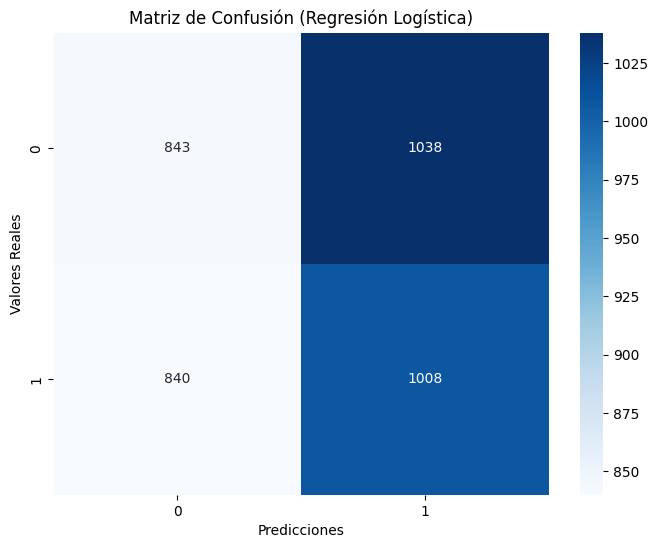

In [94]:
# Regresión logística

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

# 1. Definir variables predictoras y objetivo
X = startups_df_cleaned.drop(columns=['Profitability']) # Asegúrate de excluir columnas no numéricas
y = startups_df_cleaned['Profitability']

# 2. División de datos en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Entrenamiento del modelo de Regresión Logística
# Puedes ajustar los hiperparámetros del modelo si lo deseas
lr_model = LogisticRegression(random_state=42, solver='liblinear', multi_class='auto')
lr_model.fit(X_train, y_train)

# 4. Predicciones
y_pred = lr_model.predict(X_test)

# 5. Evaluación del modelo
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# 6. Visualización de la Matriz de Confusión (opcional, usando seaborn)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=lr_model.classes_, yticklabels=lr_model.classes_)
plt.xlabel('Predicciones')
plt.ylabel('Valores Reales')
plt.title('Matriz de Confusión (Regresión Logística)')
plt.show()


Matriz de Confusión (Gradient Boosting):
 [[885 996]
 [904 944]]

Reporte de Clasificación (Gradient Boosting):
               precision    recall  f1-score   support

           0       0.49      0.47      0.48      1881
           1       0.49      0.51      0.50      1848

    accuracy                           0.49      3729
   macro avg       0.49      0.49      0.49      3729
weighted avg       0.49      0.49      0.49      3729

Accuracy (Gradient Boosting): 0.4904800214534728


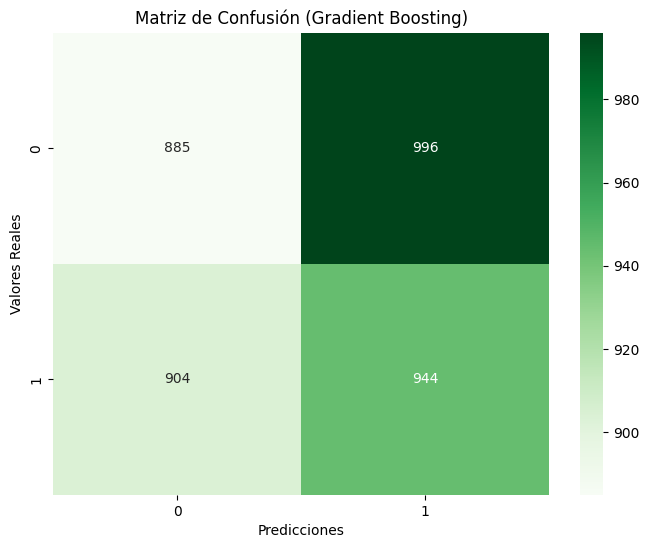

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd


# 1. Definir variables predictoras y objetivo
X = startups_df_cleaned.drop(columns=['Profitability'])

y = startups_df_cleaned['Profitability']

# 2. División de datos en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Entrenamiento del modelo Gradient Boosting Classifier
# Puedes ajustar los hiperparámetros del modelo para optimizar el rendimiento
gbm_model = GradientBoostingClassifier(n_estimators=100, # Número de árboles a construir
                                       learning_rate=0.1, # Tasa de aprendizaje
                                       max_depth=3,      # Profundidad máxima de cada árbol
                                       random_state=42)
gbm_model.fit(X_train, y_train)

# 4. Predicciones
y_pred = gbm_model.predict(X_test)

# 5. Evaluación del modelo
print("Matriz de Confusión (Gradient Boosting):\n", confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación (Gradient Boosting):\n", classification_report(y_test, y_pred))
print("Accuracy (Gradient Boosting):", accuracy_score(y_test, y_pred))

# 6. Visualización de la Matriz de Confusión (opcional, usando seaborn)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=gbm_model.classes_, yticklabels=gbm_model.classes_)
plt.xlabel('Predicciones')
plt.ylabel('Valores Reales')
plt.title('Matriz de Confusión (Gradient Boosting)')
plt.show()
